In [4]:
#2.1 Load & Inspect
import pandas as pd
df = pd.read_csv("house_prices.csv")
print(df.shape)
print(df.head())

(187531, 21)
   Index                                              Title  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...   

                                         Description Amount(in rupees)  \
0  Bhiwandi, Thane has an attractive 1 BHK Flat f...           42 Lac    
1  One can find this stunning 2 BHK flat for sale...           98 Lac    
2  Up for immediate sale is a 2 BHK apartment in ...          1.40 Cr    
3  This beautiful 1 BHK Flat is available for sal...           25 Lac    
4  This lovely 2 BHK Flat in Pokhran Road, Thane ...          1.60 Cr    

   Price (in rupees) location Carpet Area         Status         Floor  \
0             6000.0    thane    500 sqft  Ready to Move  10 out of 11   
1            13

In [5]:
print(df.columns)
print(df.info())

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transacti

In [6]:
print(df.describe())

               Index  Price (in rupees)  Dimensions  Plot Area
count  187531.000000       1.698660e+05         0.0        0.0
mean    93765.000000       7.583772e+03         NaN        NaN
std     54135.681003       2.724171e+04         NaN        NaN
min         0.000000       0.000000e+00         NaN        NaN
25%     46882.500000       4.297000e+03         NaN        NaN
50%     93765.000000       6.034000e+03         NaN        NaN
75%    140647.500000       9.450000e+03         NaN        NaN
max    187530.000000       6.700000e+06         NaN        NaN


In [7]:
print(df.isnull().sum())
print(df.duplicated().sum())

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64
0


Which columns have the most missing values?
Dimensions: 14,365 missing values
Plot Area: 14,365 missing values
Car Parking: 8,639 missing values
Super Area: 7,783 missing values
facing: 6,589 missing values
Carpet Area: 6,587 missing values
overlooking: 6,366 missing values
Society: 6,001 missing values
Ownership:5,565 missing values
Balcony:4,850 missing values

In [8]:
print("Numeric columns:",df.select_dtypes(include="number").columns.tolist())
print("Categorical columns:",df.select_dtypes(include="object").columns.tolist())

Numeric columns: ['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area']
Categorical columns: ['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area']


How many rows? 14,365 rows
Which columns are numeric vs text?
The numeric columns are: `Index`, `Price (in rupees)`, `Dimensions`, `Plot Area`
The text/categorical columns are: `Title`, `Description`, `Amount(in rupees)`, `location`, `Carpet Area`, `Status`, `Floor`, `Transaction`, `Furnishing`, `facing`, `overlooking`, `Society`, `Bathroom`, `Balcony`, `Car Parking`, `Ownership`, `Super Area`

In [9]:
#2.3 Cleaning & Feature Engineering
#1. Price is text() Convert to a number (1 Lac = 100,000 ₹; 1 Cr = 10,000,000 ₹) and drop rows without a usable price)
def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7

        return float(x.replace(",", ""))

    except ValueError:
        return None


df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df = df.dropna(subset=["price_clean"])


In [10]:
#2. Areas are text — Carpet Area / Super Area look like "1200 sqft" or "140 sqm" . Extract the number and normalise the unit to sqft (1 sqm ≈ 10.764 sqft)
import re

def parse_area(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    # Extract the number
    match = re.search(r"[\d.]+", x)

    if not match:
        return None

    value = float(match.group())

    # Convert sqm to sqft
    if "sqm" in x:
        value = value * 10.764

    return value
df["carpet_area_clean"] = df["Carpet Area"].apply(parse_area)
df["super_area_clean"] = df["Super Area"].apply(parse_area)

In [11]:
#3. Floor looks like "3 out of 10" → extract the floor number (handle , Ground , Basement)
def parse_floor(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    # Basement
    if "basement" in x:
        return -1

    # Ground floor
    if "ground" in x:
        return 0

    # Extract the first number
    match = re.search(r"\d+", x)

    if match:
        return int(match.group())

    return None
df["floor_clean"] = df["Floor"].apply(parse_floor)

In [12]:
#4. Bathroom / Balcony / Car Parking ( convert to numeric, impute missing with median or 0 )
df["Bathroom_clean"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["Bathroom_clean"] = df["Bathroom_clean"].fillna(df["Bathroom_clean"].median())

df["Balcony_clean"] = pd.to_numeric(df["Balcony"], errors="coerce")
df["Balcony_clean"] = df["Balcony_clean"].fillna(df["Balcony_clean"].median())

df["Car_Parking_clean"] = (df["Car Parking"].astype(str).str.extract(r"(\d+)", expand=False))
df["Car_Parking_clean"] = pd.to_numeric(df["Car_Parking_clean"],errors="coerce")
df.loc[df["Car_Parking_clean"] > 10, "Car_Parking_clean"] = None
df["Car_Parking_clean"] = df["Car_Parking_clean"].fillna(df["Car_Parking_clean"].median())

In [13]:
#5. High-cardinality categoricals _ location and Society have thousands of values (keep only the top_N (e.g.50) locations  and group the rest into "other" before one-hot encoding)
print("Unique locations:", df["location"].nunique())
print("Unique societies:", df["Society"].nunique())

df["location_clean"] = df["location"]
top_locations = df["location_clean"].value_counts().head(50).index

df["location_clean"] = df["location_clean"].where(df["location_clean"].isin(top_locations),"other")

df["Society_clean"] = df["Society"]
top_societies = df["Society_clean"].value_counts().head(50).index
df["Society_clean"] = df["Society_clean"].where(df["Society_clean"].isin(top_societies),"other")

Unique locations: 81
Unique societies: 10068


In [14]:
#6. Drop useless columns _Index, Title, Description, Dimensions,  and anything mostly empty
df = df.drop(columns=["Index","Title","Description","Dimensions","Plot Area"], errors="ignore")

In [15]:
#7. Remove outliers — e.g. drop listings with absurd price-per-sqft (below the 1st or above the 99th percentile)
df["area_clean"] = df["carpet_area_clean"].fillna(df["super_area_clean"])
df["price_per_sqft"] = df["price_clean"] / df["area_clean"]

df = df[(df["area_clean"] > 0) &(df["price_per_sqft"] > 0)]

lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)

df = df[(df["price_per_sqft"] >= lower) & (df["price_per_sqft"] <= upper)].copy()


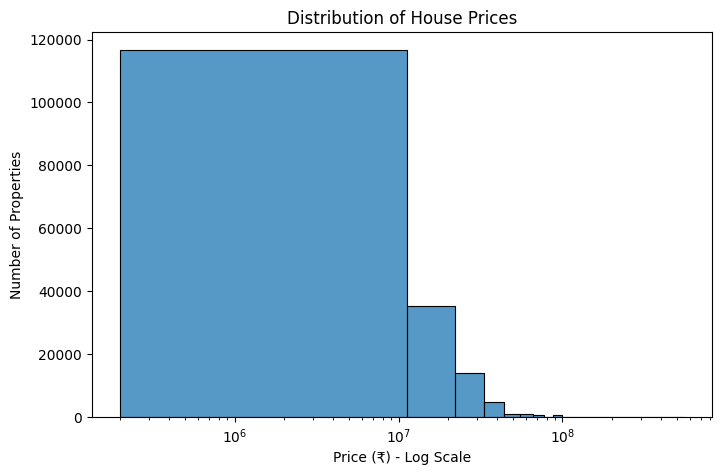

In [16]:
#2.2 Exploratory Data Analysis (EDA)
#• Distribution of the target price (it will be heavily skewed — try a log scale)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["price_clean"], bins=50)

plt.xscale("log")
plt.xlabel("Price (₹) - Log Scale")
plt.ylabel("Number of Properties")
plt.title("Distribution of House Prices")

plt.show()

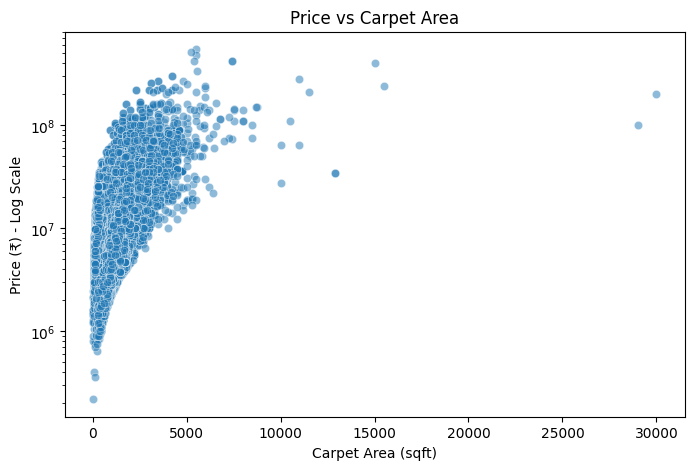

In [17]:
#Price vs. carpet area (scatter)
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="carpet_area_clean",
    y="price_clean",
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (₹) - Log Scale")
plt.title("Price vs Carpet Area")

plt.show()

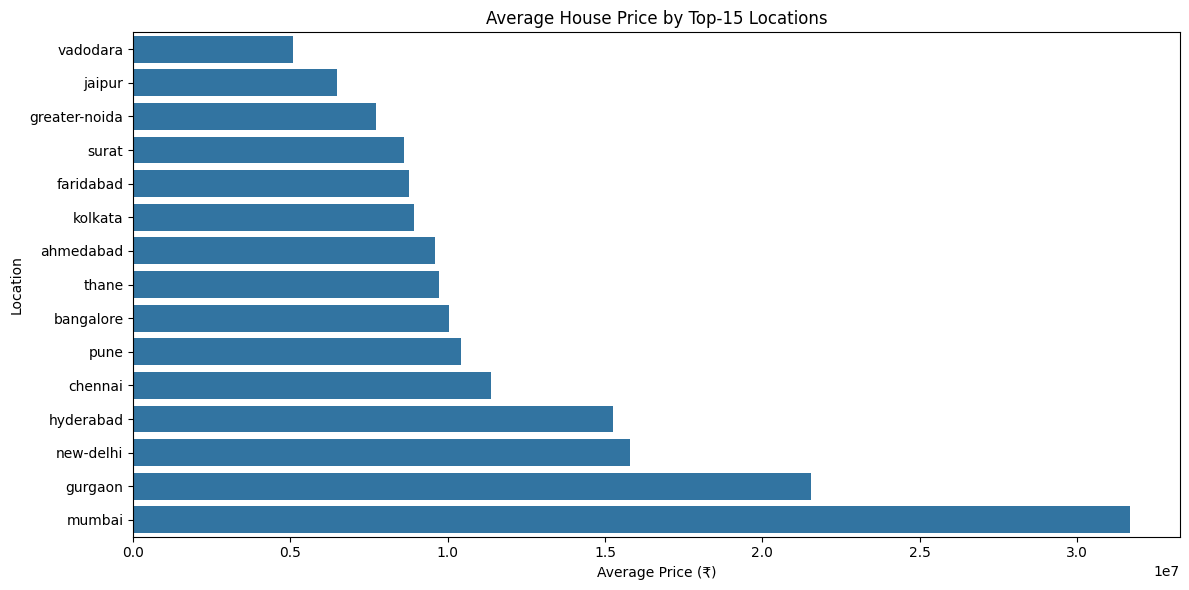

In [18]:
#Average price by top-15 locations (bar chart)
top_15_locations = df["location"].value_counts().head(15).index

avg_price_location = (
    df[df["location"].isin(top_15_locations)]
    .groupby("location")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_location = avg_price_location.sort_values()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_price_location.values,
    y=avg_price_location.index
)

plt.xlabel("Average Price (₹)")
plt.ylabel("Location")
plt.title("Average House Price by Top-15 Locations")

plt.tight_layout()
plt.show()

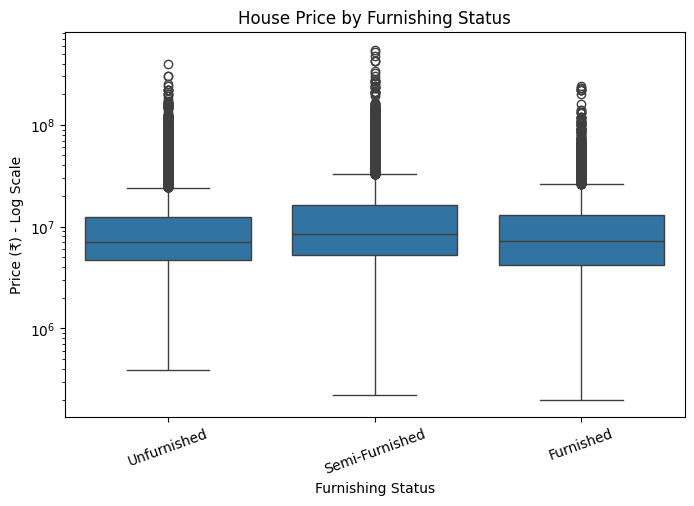

In [19]:
#Price by furnishing status(box plots)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.yscale("log")

plt.xlabel("Furnishing Status")
plt.ylabel("Price (₹) - Log Scale")
plt.title("House Price by Furnishing Status")

plt.xticks(rotation=20)

plt.show()

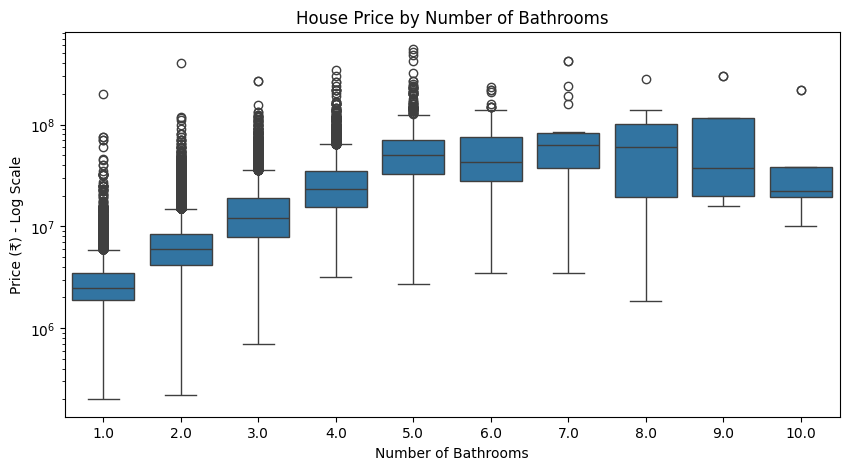

In [20]:
#Price by number of bathrooms (box plots)
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Bathroom_clean",
    y="price_clean"
)

plt.yscale("log")

plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (₹) - Log Scale")
plt.title("House Price by Number of Bathrooms")

plt.show()

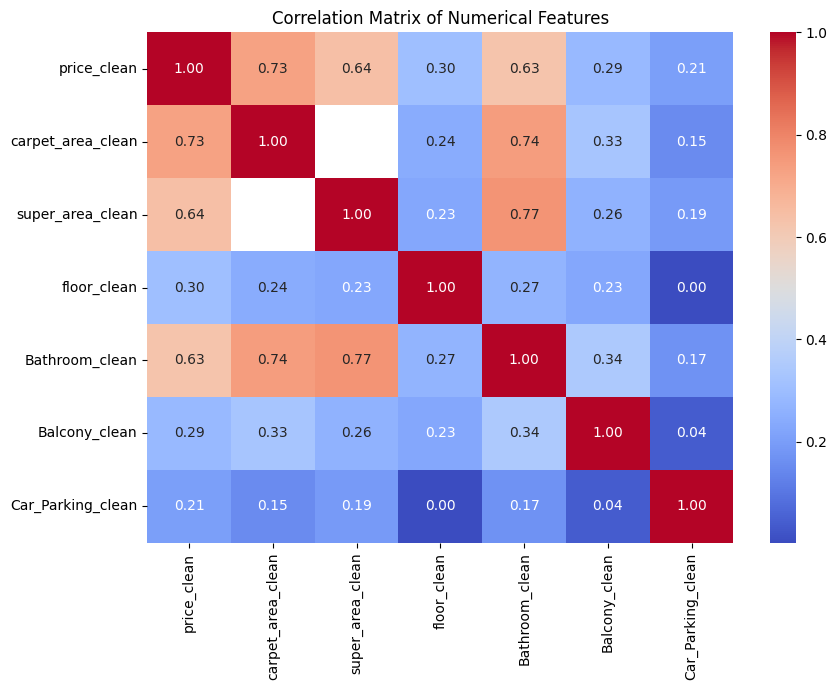

In [21]:
corr_cols = [
    "price_clean",
    "carpet_area_clean",
    "super_area_clean",
    "floor_clean",
    "Bathroom_clean",
    "Balcony_clean",
    "Car_Parking_clean"
]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [22]:
#2.4 Build a Pipeline & Train
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

numeric_features = ["carpet_area_clean","floor_clean","Bathroom_clean","Balcony_clean"]
categorical_features = ["location_clean","Furnishing","Transaction","Ownership","facing"]
X = df[numeric_features + categorical_features]
y = df["price_clean"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
# Linear Regression
linear_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [24]:
#KNN
knn_model = Pipeline([
    ("prep", preprocessor),
    ("reg", KNeighborsRegressor(
        n_neighbors=5,
        weights="distance"
    ))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [25]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
random_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_model.fit(X_train, y_train)

random_pred = random_model.predict(X_test)

In [26]:
#2.5 Evaluate
# A comparison table of all models — pick a winner and justify it in one paragrap
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

models = {
    "Linear Regression": linear_model,
    "Random Forest": random_model,
    "KNN": knn_model
}

results = []

for name, model in models.items():
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,4.585776e+06,8.231235e+06,0.602605
1,Random Forest,1.320875e+06,5.005176e+06,0.853063
2,KNN,1.395499e+06,5.297378e+06,0.835406


Random Forest was selected as the best-performing model. It achieved the lowest MAE of approximately 1.32 million and the lowest RMSE of approximately 5.01 million, while also achieving the highest R² score of 0.853. This means that the model explains about 85.3% of the variation in house prices and provides more accurate predictions than KNN and Linear Regression. KNN also performed well with an R² of 0.835, but Random Forest achieved better overall results. Therefore, Random Forest was selected as the final model for the house price prediction application.

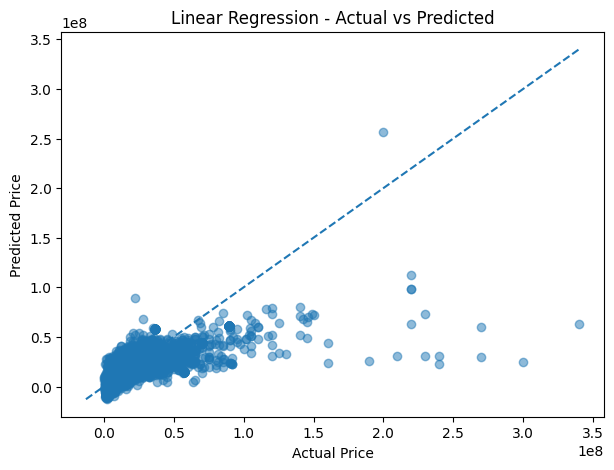

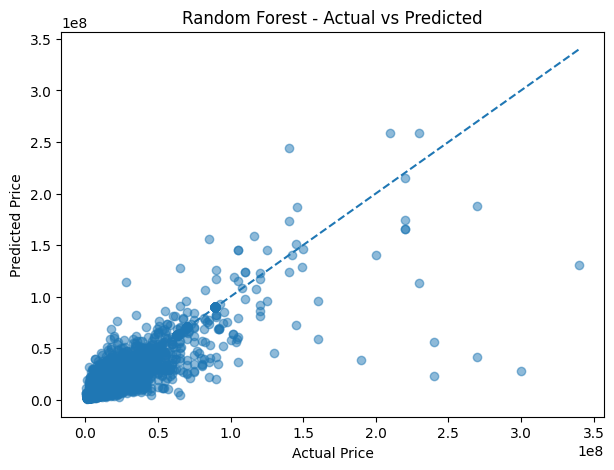

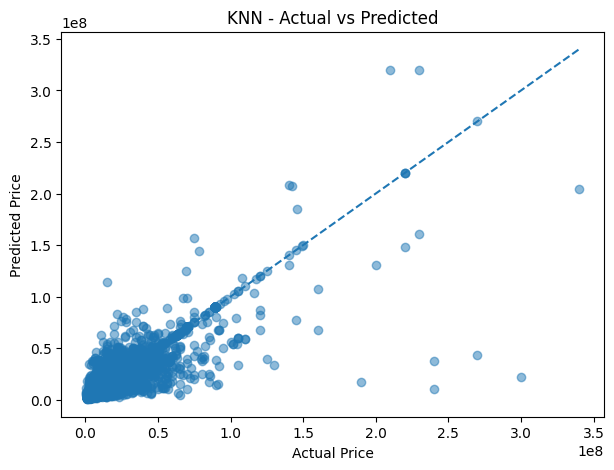

In [27]:
#A predicted vs. actual scatter plot.
import matplotlib.pyplot as plt

for name, model in models.items():

    pred = model.predict(X_test)

    plt.figure(figsize=(7, 5))

    plt.scatter(y_test, pred, alpha=0.5)

    # Perfect prediction line
    min_value = min(y_test.min(), pred.min())
    max_value = max(y_test.max(), pred.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{name} - Actual vs Predicted")

    plt.show()

In [ ]:
#Bonus: 5-Fold Cross Validation
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df

In [29]:
#2.6 Export the Model
import joblib
joblib.dump(random_model, "house_price.pkl")
print("Model saved successfully!")

Model saved successfully!


In [30]:
# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")

sample = X_test.iloc[[0]]

print("Actual price:", y_test.iloc[0])
print("Reloaded prediction:", loaded.predict(sample)[0])

Actual price: 22500000.0
Reloaded prediction: 22476957.992831565


In [31]:
#Also save the list of allowed locations (for the frontend dropdown)
import json
locations = sorted(df["location_clean"].dropna().unique().tolist())
with open("locations.json", "w") as f:
    json.dump(locations, f)
print(f"Saved {len(locations)} locations.")

Saved 51 locations.


In [33]:
print(X.columns.tolist())
for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    print(col, df[col].dropna().unique())

['carpet_area_clean', 'floor_clean', 'Bathroom_clean', 'Balcony_clean', 'location_clean', 'Furnishing', 'Transaction', 'Ownership', 'facing']
Furnishing ['Unfurnished' 'Semi-Furnished' 'Furnished']
Transaction ['Resale' 'New Property' 'Other' 'Rent/Lease']
Ownership ['Freehold' 'Co-operative Society' 'Power Of Attorney' 'Leasehold']
facing ['East' 'West' 'North - East' 'North' 'North - West' 'South' 'South -West'
 'South - East']
